https://github.com/jgehrcke/covid-19-germany-gae/blame/master/cases-rki-by-ags.csv

data saved in same folder as other survstat data

## dataprocessing

In [ ]:
from src.utils import get_data_env
import os 
import pandas as pd
from itertools import product

raw_data = pd.read_csv(os.path.join(get_data_env(),'raw/cases-rki-by-ags.csv'))
raw_data['timestamp'] =  pd.to_datetime(raw_data['time_iso8601']).dt.date
raw_data.drop(columns = ['time_iso8601'], inplace = True)

raw_data_long           =  raw_data.melt(id_vars = 'timestamp', var_name='nuts3', value_name='cases')
raw_data_long['nuts3']  = raw_data_long['nuts3'].str.zfill(5)

# one error in nuts3: 16056 has become part of 16063
raw_data_long.loc[raw_data_long['nuts3'] == '16056', 'nuts3'] = '16063'

# Filter out unwanted nuts3 codes FIRST
filter_nuts = ['11001','11002','11003','11004','11005','11006','11007','11008','11009','11010','11011','11012','sum_cases']
raw_data_long = raw_data_long[~raw_data_long['nuts3'].isin(filter_nuts)]

# Group by timestamp and nuts3
raw_data_long = raw_data_long.groupby(['timestamp','nuts3'])['cases'].sum().reset_index(drop = False)

# NOW create complete index with only the remaining nuts3 codes
all_timestamps = raw_data_long['timestamp'].unique()
all_nuts3 = raw_data_long['nuts3'].unique()

complete_index = pd.DataFrame(
    list(product(all_timestamps, all_nuts3)),
    columns=['timestamp', 'nuts3']
)

# Merge to find missing combinations and fill with 0
raw_data_long = complete_index.merge(
    raw_data_long, 
    on=['timestamp', 'nuts3'], 
    how='left'
)
raw_data_long['cases'] = raw_data_long['cases'].fillna(0)

# Continue with processing
df = raw_data_long.sort_values(['nuts3', 'timestamp'])

df['daily_cases'] = df.groupby('nuts3')['cases'].diff()
df.loc[df['daily_cases'] < 0, 'daily_cases'] = 0
import seaborn as sns
df['timestamp'] = pd.to_datetime(df['timestamp'])
sns.lineplot(df[df['nuts3'] == '11000'], x = 'timestamp', y = 'daily_cases')

preprocessed_data = df[['timestamp','nuts3','daily_cases']].rename(columns = {'daily_cases':'cases','nuts3':'kz_kreis'})
iso = df['timestamp'].dt.isocalendar()

preprocessed_data['year'] = iso.year
preprocessed_data['week'] = iso.week
preprocessed_data['day'] = iso.day

preprocessed_data.loc[preprocessed_data['cases'].isna(), 'cases'] = 0
preprocessed_data.reset_index(drop = True, inplace=True)
preprocessed_data = preprocessed_data[['week','kz_kreis','cases','year','timestamp','day']]
preprocessed_data.to_csv(os.path.join(get_data_env(),'processed/germany/epidemiology/casedata/survstat/covid_daily.csv'), index=False)

## dataloading

In [ ]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, ShallowDataLoaderManager, GraphDataLoaderManager, DeepDataLoaderManager
from src.models import ConstantModel, PersistenceModel, ClimateologyModel, NodeLSTMModel, NodeGRUModel, GATv2Model, SpatialGNNModel

# get data
disease_name    = 'covid_daily'
nuts_level      = 'nuts3'
min_date        = '2020-03-02'
max_date        = '2023-01-01'
split_trainval  = '2022-01-01'
split_valtest   = '2022-03-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 5
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    temporal_frequency   = "d",
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = True,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0  
    )    

data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: /local/job_23466711/wissdaten/ZKI-PH4/deschrijvers_wissdaten/data/processed/germany/geospatial/shapefiles/shape_nuts3.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


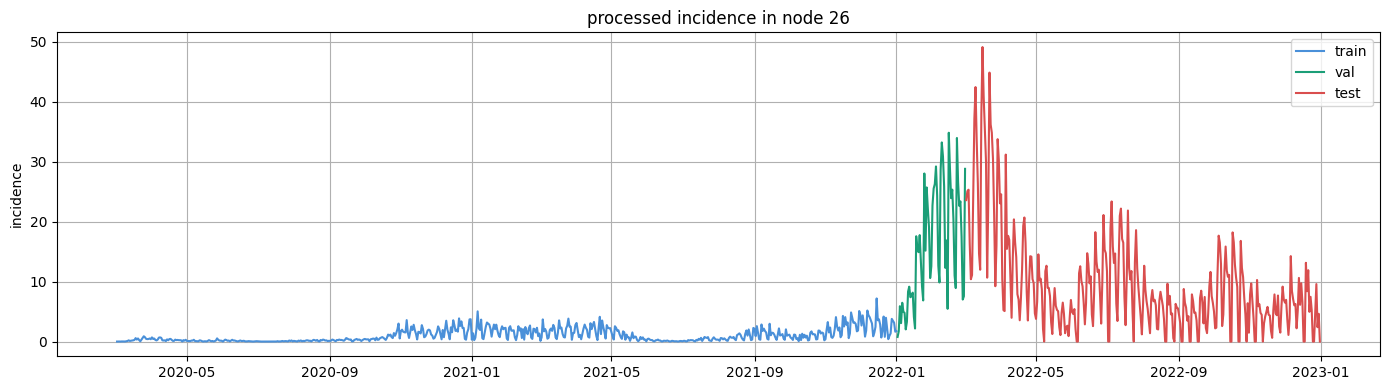

In [ ]:
data_orchestrator.preview(26).show()

In [ ]:
from src.dataloading import ShallowDataLoaderManager, GraphDataLoaderManager

In [ ]:
from src.dataloading import ShallowDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel

sl = ShallowDataLoaderManager(data_orchestrator).construct_dataloaders()
dl = DeepDataLoaderManager(data_orchestrator).construct_dataloaders()
gl = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('geographical_neighbors1').construct_dataloaders()

ps = PersistenceModel(sl)
cm = ClimateologyModel(sl)

ps.forecast('test')
raw_f1 = ps.show_forecasts([26], 'test')

cm.forecast('test')
raw_f2 = cm.show_forecasts([26], 'test')

f1 = (raw_f1
      .labels.change_suptitle('Persistence model','bold',12)
      .labels.change_title('Predictions node 26: Hannover')
      .labels.change_xlab('time')
      .labels.change_ylab('incidence')
      .legend.set_labels(['true incidence','persistence model'])
      .change_figsize(10,5).legend.move('upper left'))

f2 = (raw_f2
      .labels.change_suptitle('Climateology model','bold',12)
      .labels.change_title('Predictions node 26: Hannover')
      .labels.change_xlab('time')
      .labels.change_ylab('incidence')
      .legend.set_labels(['true incidence','climateology model'])
      .change_figsize(10,5).legend.move('upper left'))

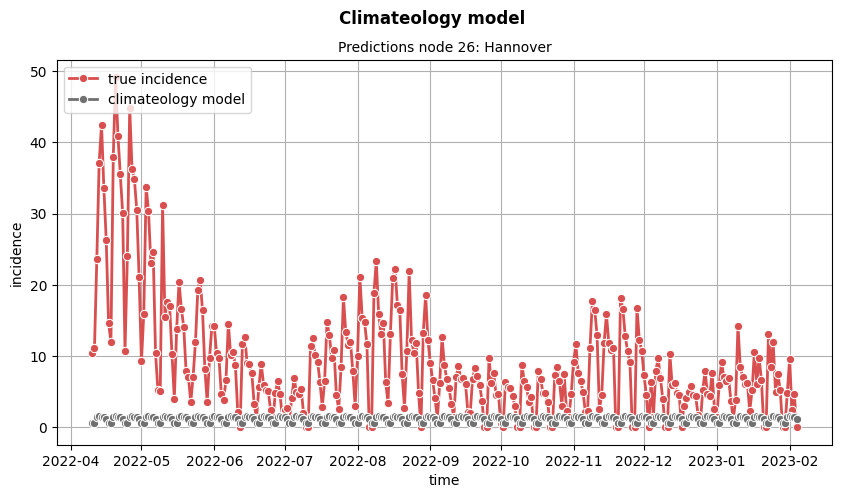

In [ ]:
f2.show()


==                   nodelstm                   ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: DeepData(x=(400, 6, 1), y=(400, 1))


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:00<00:00, 475.27it/s]


Test loss: 6.2739
forecasted ✓


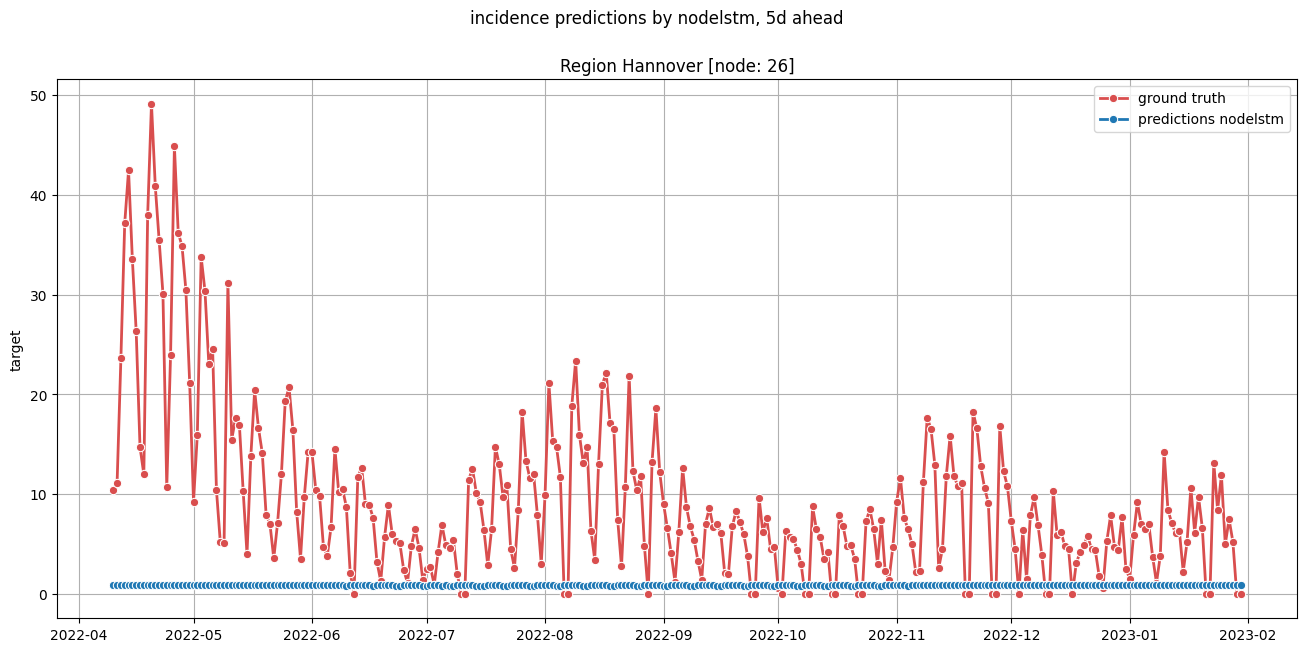

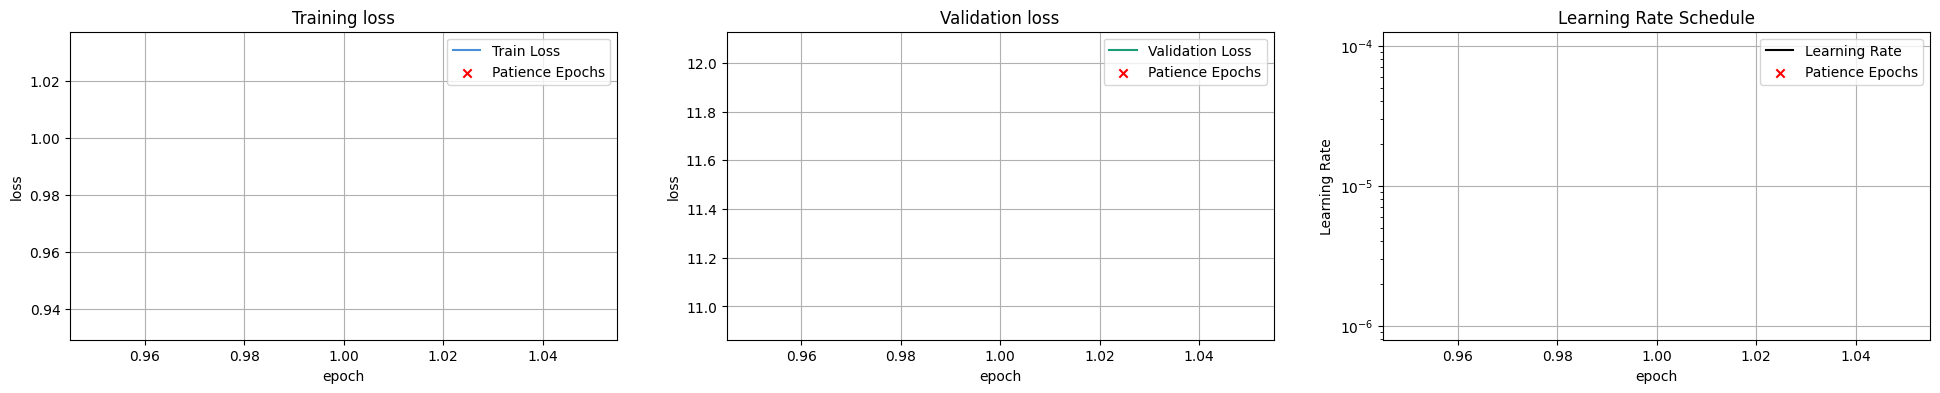

In [ ]:
from src.models import NodeLSTMModel

lr = 0.00001
n_epochs= 250
min_delta = 0
loss = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 10,
    }

lstm = NodeLSTMModel(dl, verbose = 2)
lstm.set_model_hparams()
lstm.set_global_hparams(**global_hparams)
lstm.train()
lstm.forecast('test')
lstm.show_forecasts(26).show()


==                  spatialgnn                  ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 6, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:00<00:00, 625.78it/s]


Test loss: 6.0401
forecasted ✓


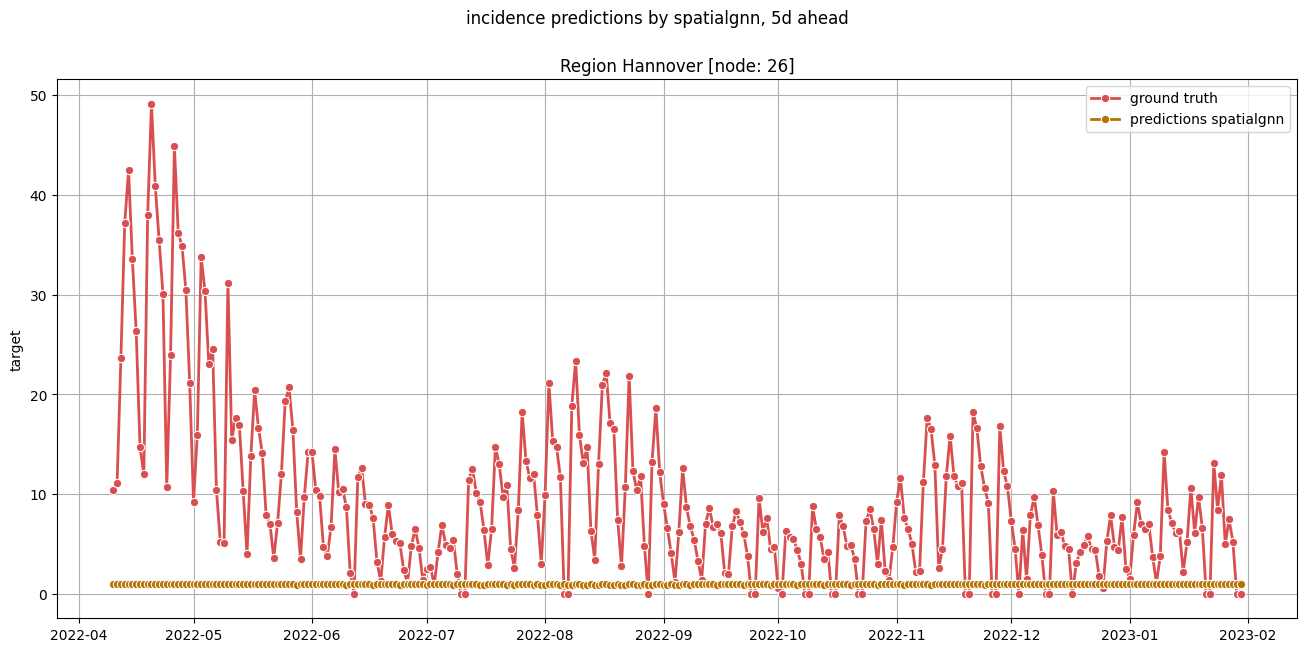

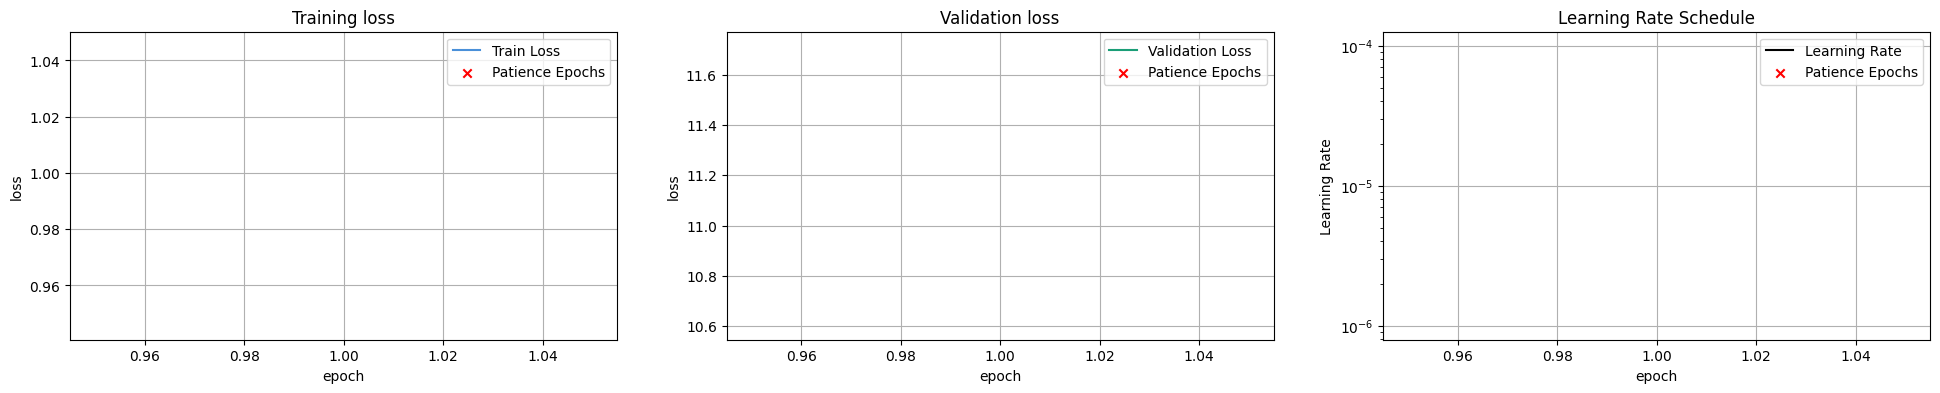

In [ ]:
from src.models import SpatialGNNModel

lr = 0.00001
min_delta = 0
loss = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 10,
    }

gcn = SpatialGNNModel(gl, verbose = 2)
gcn.set_model_hparams()
gcn.set_global_hparams(**global_hparams)
gcn.train()
gcn.forecast('test')
gcn.show_forecasts(26).show()

Forecasting val: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 59/59 [00:00<00:00, 622.88it/s]


Val loss: 11.1586
forecasted ✓


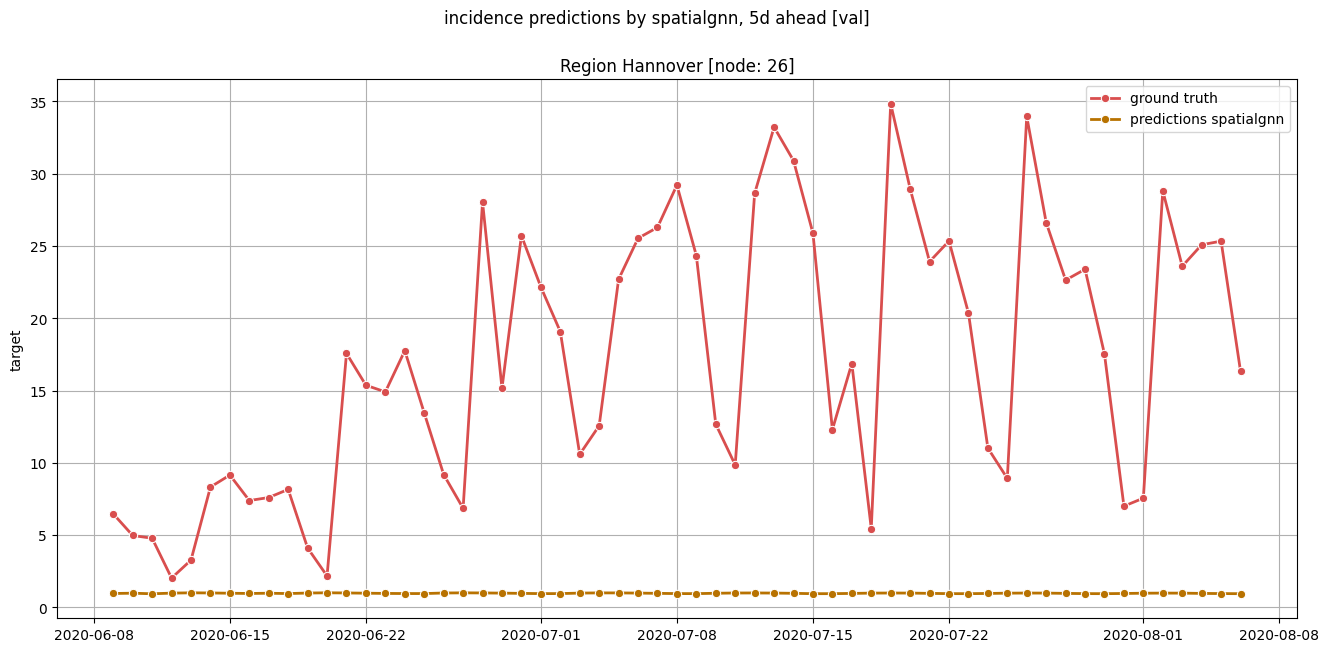

In [ ]:
gcn.forecast('val')
gcn.show_forecasts(26,'val').show()


==                  gatv2model                  ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 6, 1), y=(400, 1), edge_index=(2, 3905), edge_weight=(3905,))


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:00<00:00, 459.76it/s]


Test loss: 3.4025
forecasted ✓


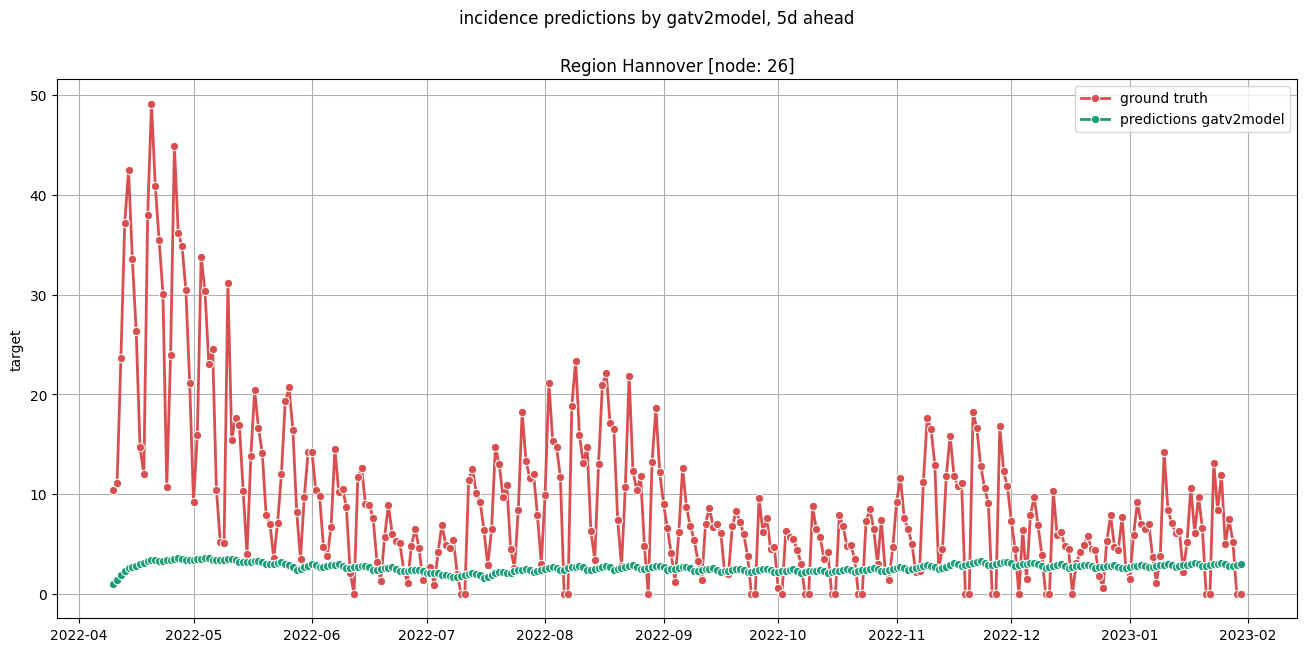

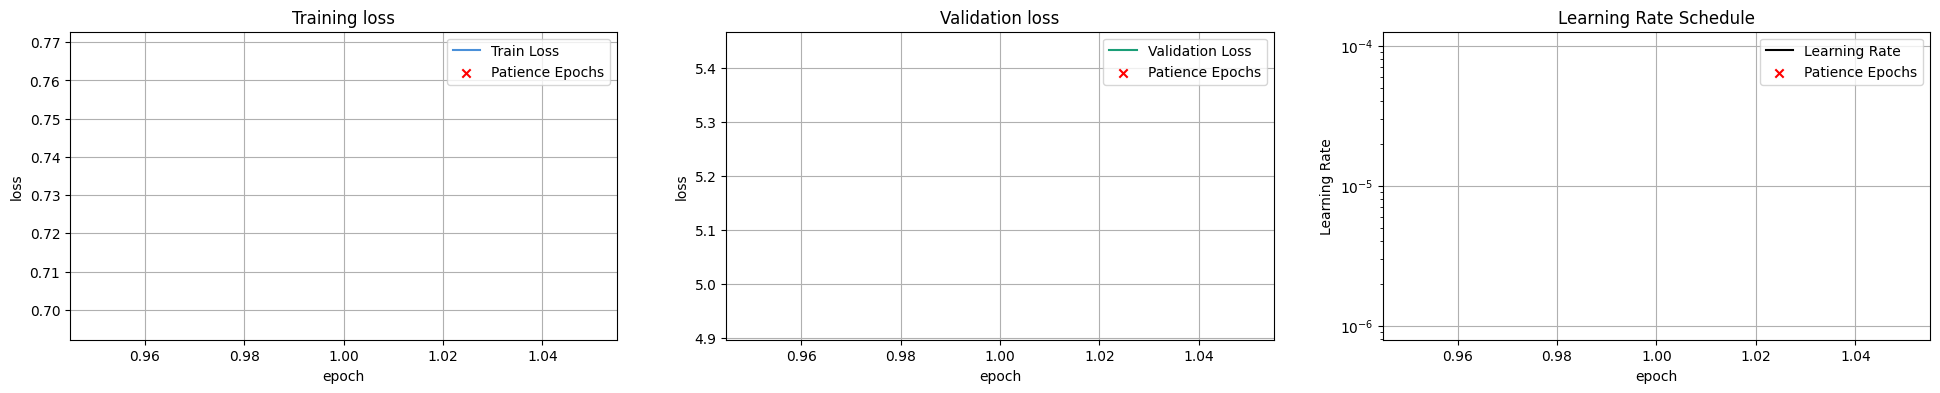

In [ ]:
from src.models import GATv2Model

lr = 0.00001
min_delta = 0
loss = 'mse'

gl = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter24_1').construct_dataloaders()


global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 10,
    }

gat = GATv2Model(gl, verbose = 2)
gat.set_model_hparams()
gat.set_global_hparams(**global_hparams)
gat.train()
gat.forecast('test')
gat.show_forecasts(26).show()

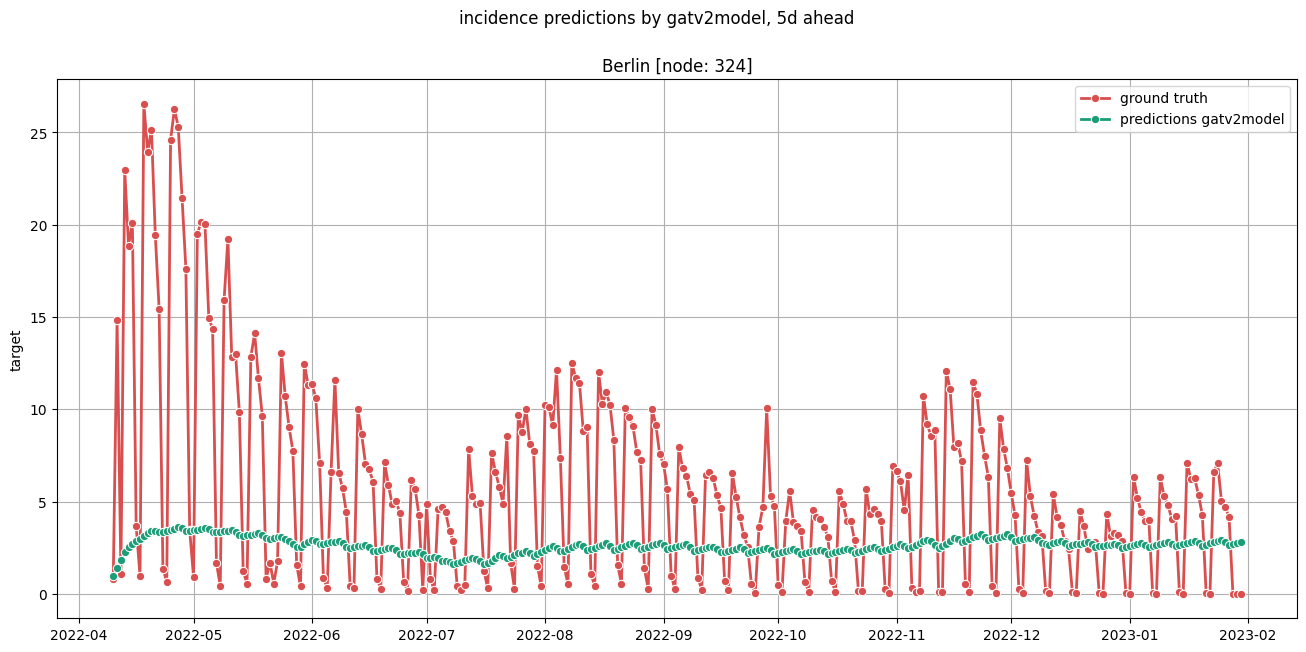

In [ ]:
gat.show_forecasts(324).show()


==                      gn                      ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 6, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:00<00:00, 463.02it/s]


Test loss: 4.1706
forecasted ✓


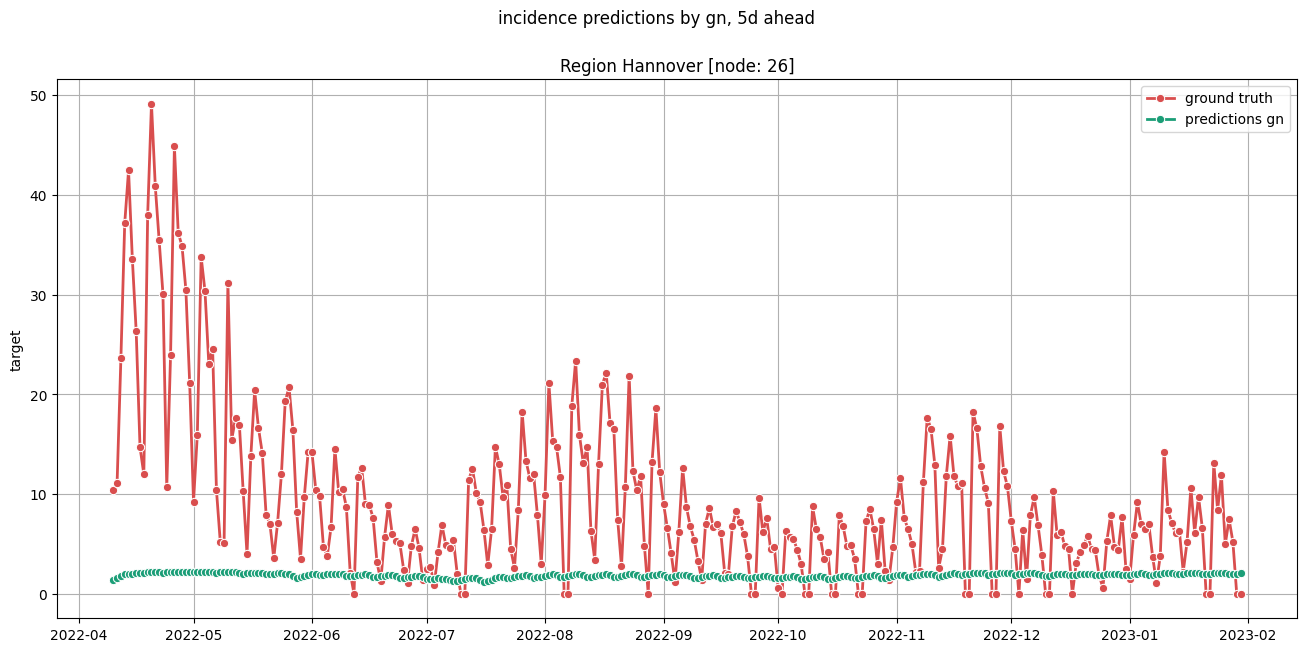

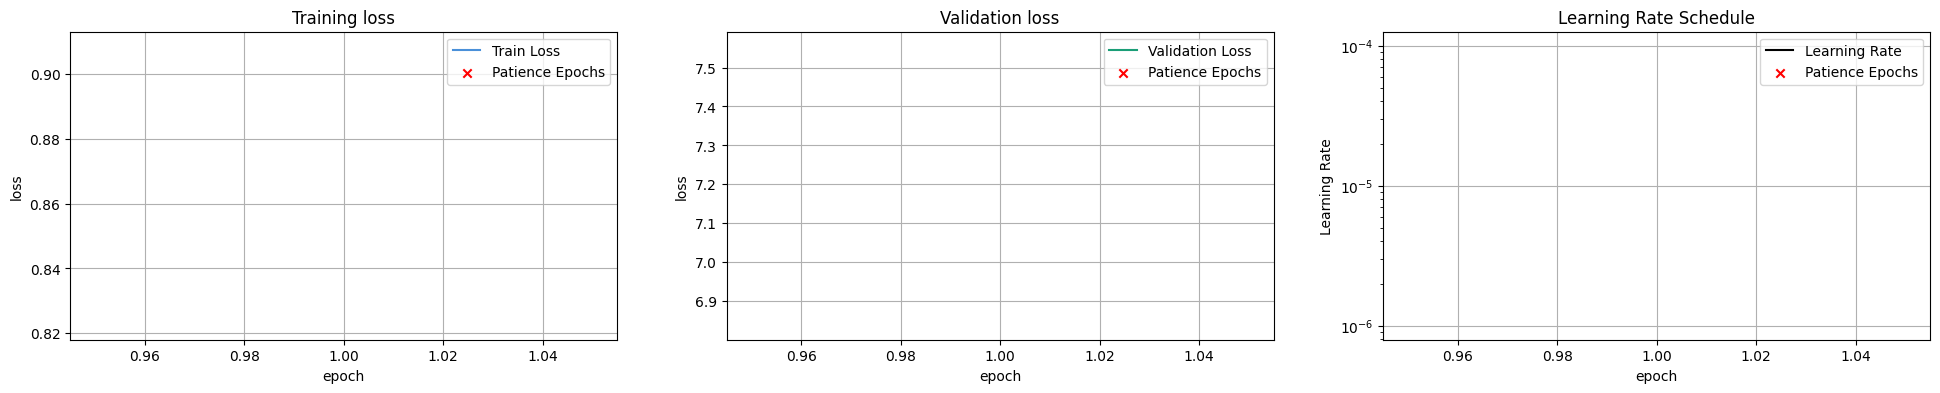

In [ ]:
gl2 = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('geographical_neighbors1').construct_dataloaders()

gat2 = GATv2Model(gl2, verbose = 2, name = 'gn')
gat2.set_model_hparams()
gat2.set_global_hparams(**global_hparams)
gat2.train()
gat2.forecast('test')
gat2.show_forecasts(26).show()

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:02<00:00,  2.87it/s]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. af

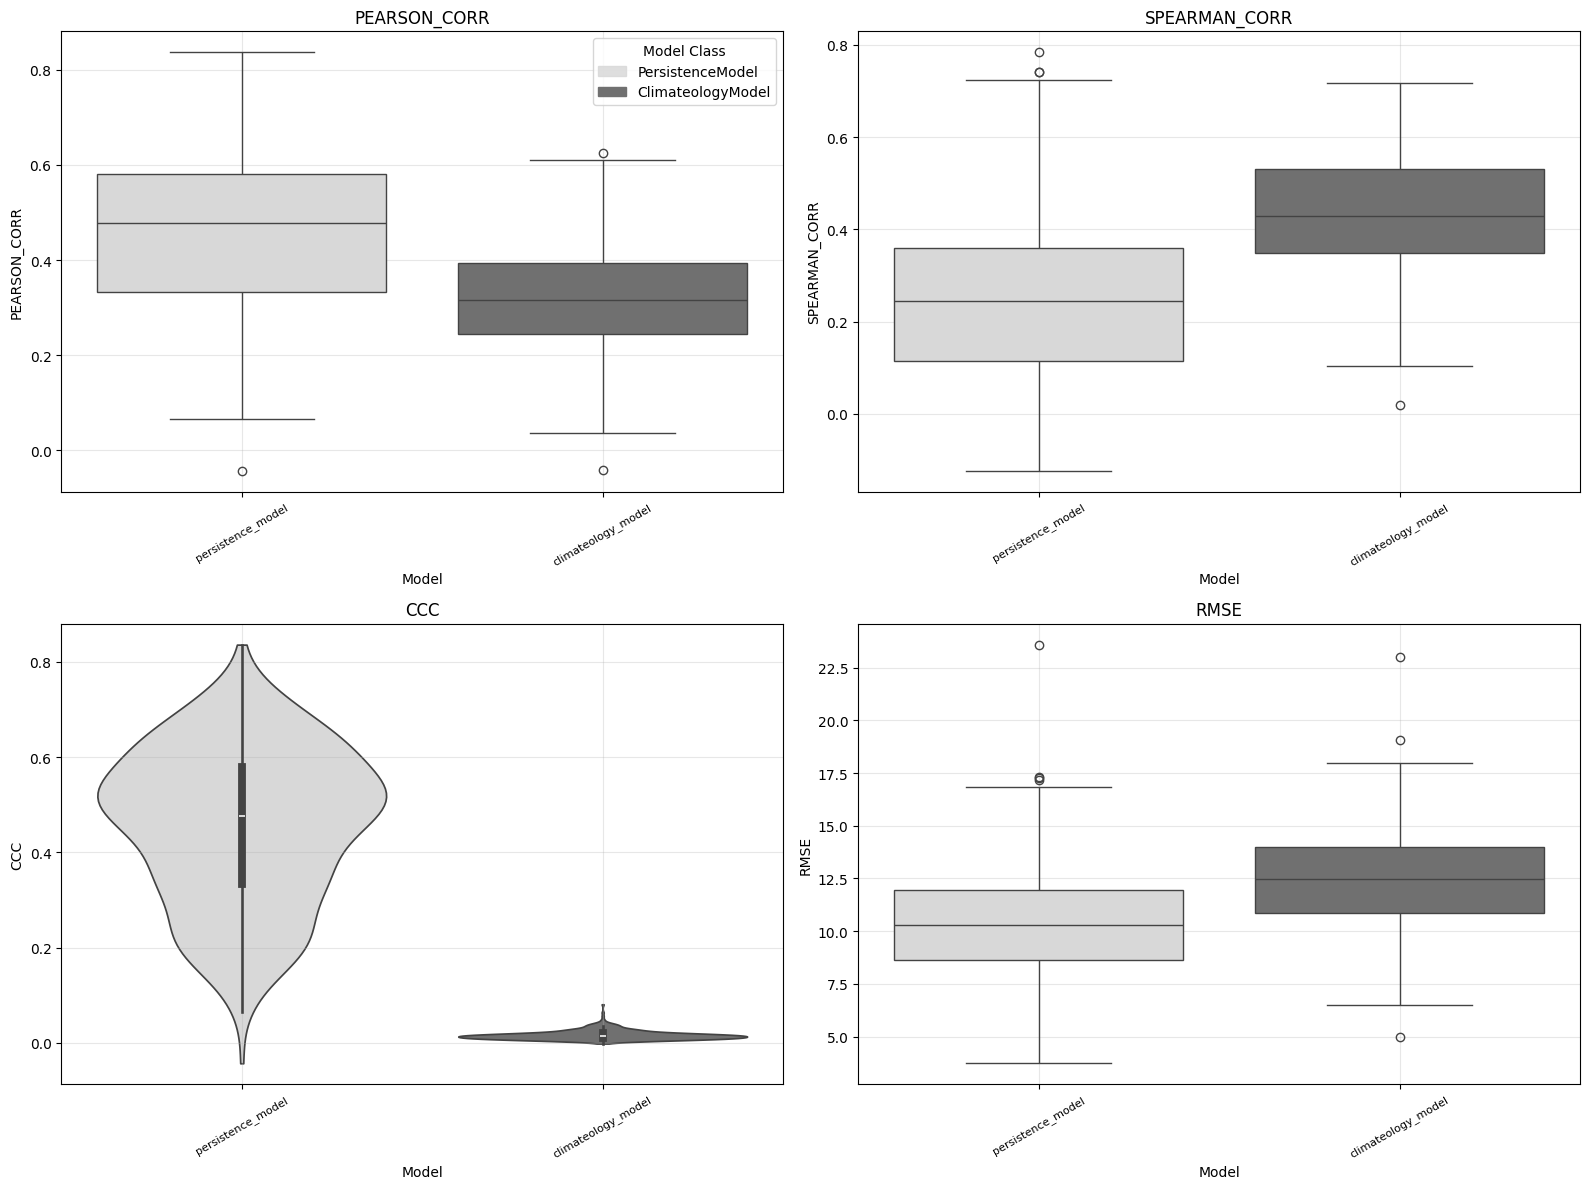

In [ ]:
from src.evaluation import Evaluator

e = Evaluator([ps, cm]).add_evaluation()
e.plotter.plot_metric_compilation(plot_types = ['box','box','violin','box']).show()

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:05<00:00,  1.15it/s]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. af

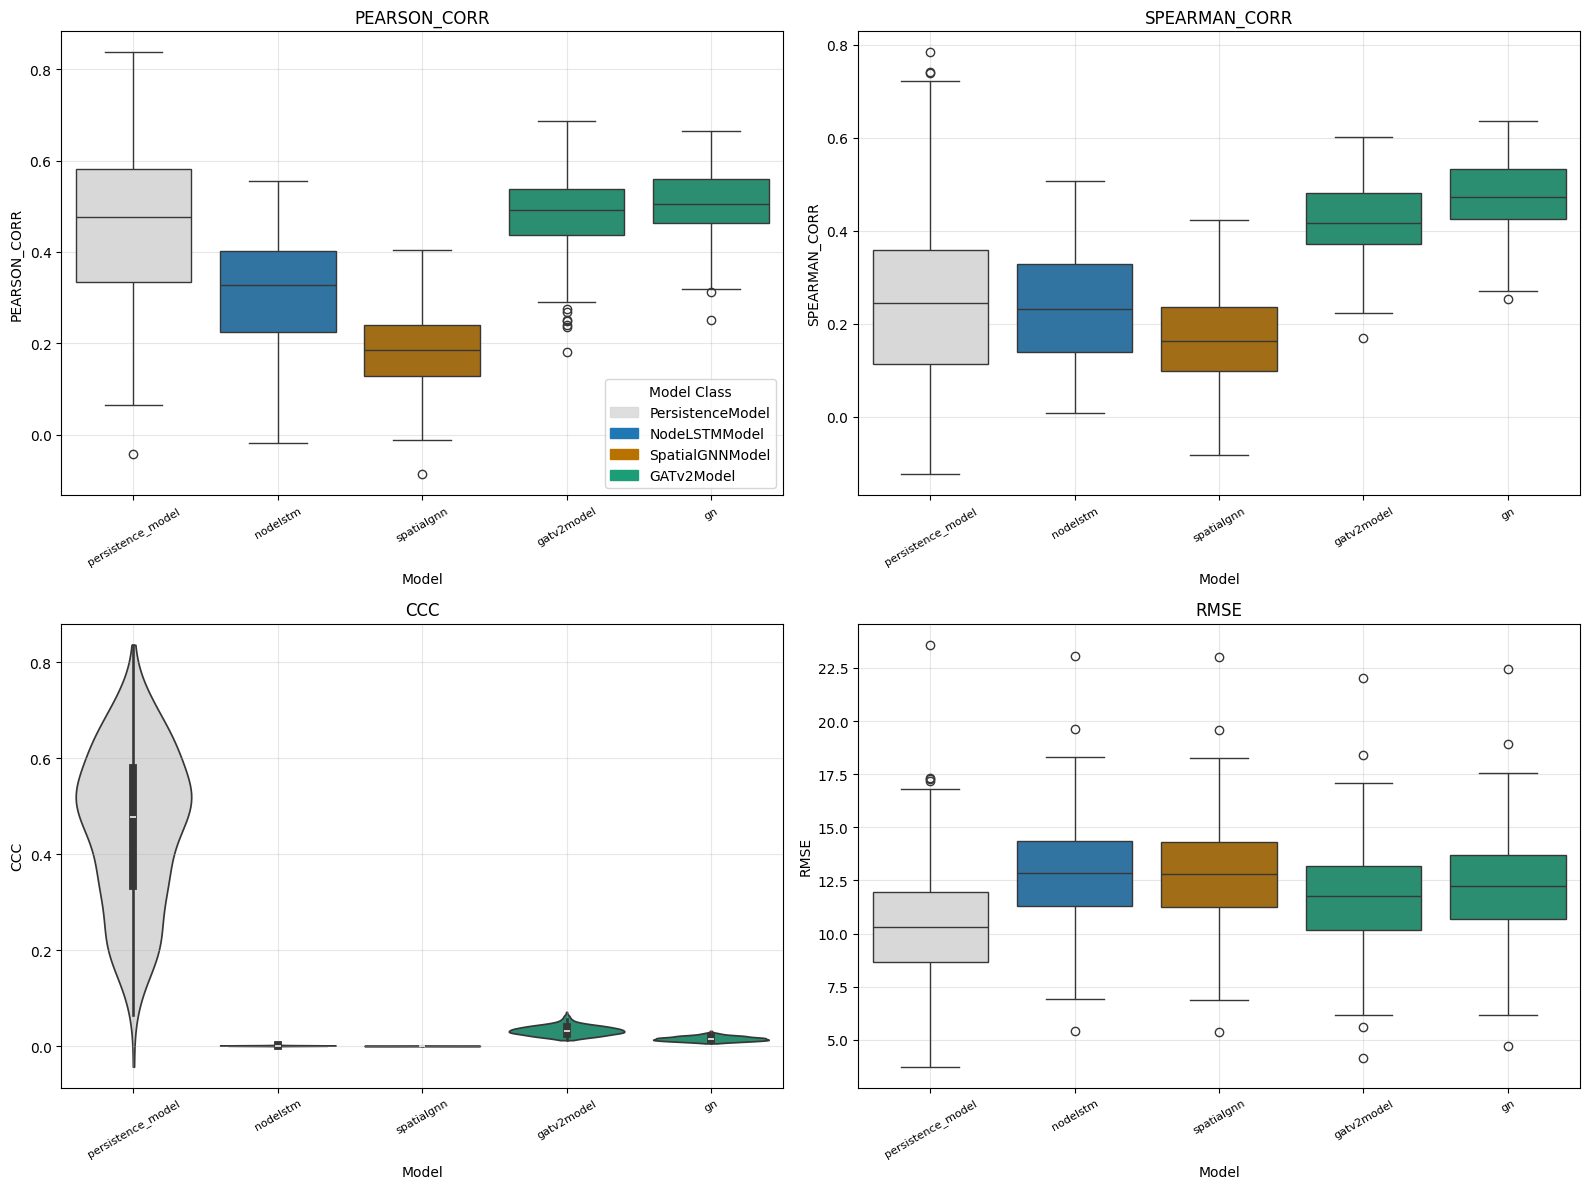

In [ ]:
from src.evaluation import Evaluator

e = Evaluator([ps, lstm, gcn, gat, gat2]).add_evaluation()
e.plotter.plot_metric_compilation(plot_types = ['box','box','violin','box']).show()